# Empulse: Value-Driven and Cost-Sensitive Machine Learning in Python

Replication notebook for the paper in the *Journal of Statistical Software*. It runs every code
example of the paper, section by section, reproduces the case study of Section 8 with its printed
output, and regenerates the two benchmark figures (the EMP integration comparison of Section 5 and
the computational performance comparison of Section 9).

**Requirements.** Python 3.11 or later and

```
pip install empulse[boosting] matplotlib
```

`xgboost` (installed by the `boosting` extra) is used by one example. The benchmark code lives in the `jss_benchmark` package next to this
notebook; run the notebook from this directory so that it can be imported.

**Runtime.** Everything up to Section 9 runs in about a minute. By default, Section 9 redraws the
benchmark figures from the raw results in `results/`, which are the results reported in the paper.
Each experiment can be rerun by switching on its flag in Section 9; see the runtimes stated there.

## Setup

In [1]:
import platform
import warnings

import matplotlib
import numpy as np
import pandas as pd
import sklearn
import sympy

import empulse

print(f'Python       {platform.python_version()} ({platform.system()})')
for module in (empulse, sklearn, np, pd, sympy, matplotlib):
    print(f'{module.__name__:12s} {module.__version__}')

Python       3.12.14 (Windows)
empulse      0.12.1-dev0
sklearn      1.9.0
numpy        2.3.3
pandas       2.3.3
sympy        1.14.0
matplotlib   3.10.6


## Section 4: Architecture of Empulse

### 4.1 Symbolic foundations and the builder API

The customer churn cost matrix: a contacted churner accepts the retention offer with probability
$\gamma$, which costs the incentive $\delta \cdot clv$ and the contact cost $f$; a contacted
non-churner costs the same.

In [2]:
import sympy

from empulse.metrics import CostMatrix

clv, delta, f, gamma = sympy.symbols('clv delta f gamma')
cost_matrix = (
    CostMatrix()
    .add_tp_benefit(gamma * ((1 - delta) * clv - f))
    .add_tp_benefit(-(1 - gamma) * f)
    .add_fp_cost(delta * clv + f)
)
cost_matrix

CostMatrix(tp_cost=-f*(gamma - 1) - gamma*(clv*(1 - delta) - f), tn_cost=0, fp_cost=clv*delta + f, fn_cost=0)

### 4.2 Modeling stochastic costs and uncertainty

The acceptance rate becomes a Beta-distributed random variable. The incentive is written as a fixed
amount $d$ here, as in the EMP literature.

In [3]:
from sympy.stats import Beta

alpha, beta, d = sympy.symbols('alpha beta d')
gamma = Beta('gamma', alpha, beta)
stochastic_cost_matrix = (
    CostMatrix().add_tp_benefit(gamma * (clv - d - f)).add_tp_benefit((1 - gamma) * -f).add_fp_cost(d + f)
)
stochastic_cost_matrix

CostMatrix(tp_cost=f*(1 - gamma) - (clv - d - f)*gamma, tn_cost=0, fp_cost=d + f, fn_cost=0)

### 4.3 Configuration utilities

In [4]:
cost_matrix.alias({
    'incentive_fraction': 'delta',
    'contact_cost': 'f',
    'accept_rate': 'gamma',
})
cost_matrix.set_default(incentive_fraction=0.05, contact_cost=1, accept_rate=0.3)

CostMatrix(tp_cost=-f*(gamma - 1) - gamma*(clv*(1 - delta) - f), tn_cost=0, fp_cost=clv*delta + f, fn_cost=0)

## Section 5: Evaluation metrics

### 5.1 The unified metric API

*Added in the notebook:* the paper assumes a trained model and a metric. Here, a logistic
regression is trained on the churn data of Section 7, with the same split as the case study, and
the metric is the Expected Maximum Profit of Section 4 (`Metric(cost_matrix, MaxProfit())`).

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from empulse.datasets import fetch_iranian_churn
from empulse.metrics import MaxProfit, Metric

churn = fetch_iranian_churn(backend=pd)
X_train, X_test, y_train, y_test, clv_train, clv_test = train_test_split(
    churn.data,
    churn.target,
    churn.instance_costs['clv'],
    test_size=0.3,
    random_state=42,
    stratify=churn.target,
)
clv_array = clv_test
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_train, y_train)
metric = Metric(cost_matrix, MaxProfit())

In [6]:
# Assume a trained probabilistic model and an instantiated metric
y_proba = model.predict_proba(X_test)[:, 1]

# 1. Compute the expected business impact
print(metric.score(y_test, y_proba, clv=clv_array))
# or through the equivalent __call__
print(metric(y_test, y_proba, clv=clv_array))

# 2. Find the optimal probability cutoff for decision making
print(metric.optimal_threshold(y_test, y_proba, clv=clv_array))

# 3. Find the optimal target volume (e.g., target the top 15%)
print(metric.optimal_rate(y_test, y_proba, clv=clv_array))

15.403961551552309
15.403961551552309
0.27889956739224986
0.21481481481481482


### 5.2 Expected cost

*Added in the notebook:* four illustrative customers, matching the four instance-dependent
customer lifetime values of the example.

In [7]:
y_true = np.array([0, 1, 1, 0])
y_pred = np.array([0.2, 0.8, 0.6, 0.4])

In [8]:
from empulse.metrics import Cost, Metric

cost_loss = Metric(cost_matrix=cost_matrix, strategy=Cost())
result = cost_loss(
    y_true,
    y_pred,
    accept_rate=0.3,
    clv=[20, 10, 15, 5],  # Instance-dependent costs
)
result

-0.63625

### 5.3 Expected savings

*Added in the notebook:* the baseline scores come from a logistic regression, as in the paper,
fitted here on four illustrative feature vectors for the four customers above.

In [9]:
X = np.array([[0.1, 1.2], [1.5, 0.3], [0.9, 0.8], [0.4, 1.0]])
logistic_regression = LogisticRegression().fit(X, y_true)

In [10]:
from empulse.metrics import Savings

savings_metric = Metric(cost_matrix=cost_matrix, strategy=Savings())
y_pred_baseline = logistic_regression.predict_proba(X)[:, 1]
custom_savings = savings_metric(
    y_true,
    y_pred,
    accept_rate=0.3,
    clv=[20, 10, 15, 5],
    baseline=y_pred_baseline,  # User-defined general baseline S^b
)
custom_savings

-0.4551522872521401

### 5.4 Expected maximum profit

In [11]:
from empulse.metrics import MaxProfit

# The strategy automatically selects analytical or numerical integration
emp_score = Metric(cost_matrix=stochastic_cost_matrix, strategy=MaxProfit(integration_method='auto'))
result = emp_score(y_true, y_pred, alpha=6, beta=14, clv=200, d=10, f=1)
result

28.00000000003913

The comparison of integration methods (the EMP integration figure) is reproduced in Section 9
below, together with the other benchmarks.

## Section 6: Estimators and scikit-learn integration

### 6.1 The estimator workflow and contract

`metric` is the Expected Maximum Profit metric of Section 5.1.

In [12]:
from empulse.models import CSBoostClassifier

model = CSBoostClassifier(loss=metric)
model.fit(X_train, y_train, clv=clv_train)

,loss,Metric(cost_m...rator(PCG64)))
,estimator,None
,tp_cost,0.0
,tn_cost,0.0
,fn_cost,0.0
,fp_cost,0.0
Name,Type,Value
classes_,"ndarray[int8](2,)","[0,1]"
estimator_,XGBClassifier,"XGBClassifier...ree=None, ...)"
feature_names_in_,"ndarray[object](12,)","['call_failure','complains','subscription_length',...,'tariff_plan', 'status','age']"
n_features_in_,int,12


### 6.2 The optimizer module

*Added in the notebook:* the features are standardized first, as gradient-based optimizers expect.

In [13]:
X_train_scaled = StandardScaler().fit_transform(X_train)

In [14]:
from empulse.models import CSLogitClassifier
from empulse.optimizers import Adam

model = CSLogitClassifier(optimizer=Adam(lr=0.01, max_iter=100))
model.fit(X_train_scaled, y_train, fp_cost=5, fn_cost=1)

,optimizer,<empulse.opti...0023C3FEC63F0>
,tp_cost,0.0
,tn_cost,0.0
,fn_cost,0.0
,fp_cost,0.0
,C,1.0
,fit_intercept,True
,l1_ratio,1.0
,loss,None
,n_jobs,1
Name,Type,Value


### 6.3 The samplers module

In [15]:
from empulse.samplers import CostSensitiveSampler

sampler = CostSensitiveSampler(loss=cost_loss, method='oversampling')
X_re, y_re = sampler.fit_resample(X_train, y_train, clv=clv_train, accept_rate=0.3)
print(f'{len(y_train)} training instances resampled to {len(y_re)}')

2205 training instances resampled to 6105


### 6.4 Scikit-learn integration and metadata routing

`clv_array` holds the customer lifetime values of the training instances here.

In [16]:
clv_array = clv_train

In [17]:
import sklearn
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

from empulse.models import CSBoostClassifier

sklearn.set_config(enable_metadata_routing=True)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', CSBoostClassifier(XGBClassifier(), loss=cost_loss).set_fit_request(clv=True)),
])
scorer = make_scorer(cost_loss, response_method='predict_proba', greater_is_better=False)
scorer.set_score_request(clv=True)
search = GridSearchCV(pipeline, param_grid={'model__estimator__n_estimators': [50, 100]}, scoring=scorer)
search.fit(X_train, y_train, clv=clv_array)
print(search.best_params_, search.best_score_)

{'model__estimator__n_estimators': 50} 4.205463012894043


## Section 7: Benchmark datasets

*Added in the notebook:* `y_score` holds out-of-fold churn probabilities of a logistic regression.

In [18]:
from sklearn.model_selection import cross_val_predict

y_score = cross_val_predict(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    churn.data,
    churn.target,
    cv=5,
    method='predict_proba',
)[:, 1]

In [19]:
import pandas as pd

from empulse.datasets import fetch_iranian_churn
from empulse.metrics import Metric, Profit

dataset = fetch_iranian_churn(backend=pd)
metric = Metric(dataset.cost_matrix, Profit())
profit = metric(dataset.target, y_score, **dataset.instance_costs)
profit

2.356430835049623

## Section 8: Case study: customer churn prediction

The code below is the paper's case study, cell for cell. Its output matches the output printed in
the paper.

### 8.1 Evaluating a standard baseline

In [20]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from empulse.datasets import fetch_iranian_churn
from empulse.metrics import Metric, Profit

dataset = fetch_iranian_churn(backend=pd)
X, y = dataset.data, dataset.target
clv = dataset.instance_costs['clv']
profit_score = Metric(dataset.cost_matrix, Profit())

X_train, X_test, y_train, y_test, clv_train, clv_test = train_test_split(
    X, y, clv, test_size=0.3, random_state=42, stratify=y
)

baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42)),
]).fit(X_train, y_train)

y_score_base = baseline.predict_proba(X_test)[:, 1]

print(f'AUC: {roc_auc_score(y_test, y_score_base):.3f}')
print(f'Accuracy: {accuracy_score(y_test, (y_score_base >= 0.5)):.3f}')
profit = profit_score(y_test, y_score_base, clv=clv_test)
print(f'Expected profit: {profit:.2f}')
print(f'Fraction contacted: {(y_score_base >= 0.5).mean():.1%}')

AUC: 0.926
Accuracy: 0.889
Expected profit: 2.28
Fraction contacted: 8.6%


### 8.2 Training a cost-sensitive linear model

In [21]:
from sklearn import set_config

from empulse.models import CSLogitClassifier

set_config(enable_metadata_routing=True)

model = CSLogitClassifier(loss=profit_score).set_fit_request(clv=True)
cslogit = Pipeline([
    ('scaler', StandardScaler()),
    ('model', model),
]).fit(X_train, y_train, clv=clv_train)

y_score_cs = cslogit.predict_proba(X_test)[:, 1]

print(f'AUC: {roc_auc_score(y_test, y_score_cs):.3f}')
print(f'Accuracy: {accuracy_score(y_test, (y_score_cs >= 0.5)):.3f}')
profit = profit_score(y_test, y_score_cs, clv=clv_test)
print(f'Expected profit: {profit:.2f}')
print(f'Fraction contacted: {(y_score_cs >= 0.5).mean():.1%}')

AUC: 0.906
Accuracy: 0.849
Expected profit: 3.29
Fraction contacted: 26.6%


### 8.3 Choosing who to contact

`optimal_threshold` warns when a break-even threshold falls outside $[0, 1]$ and is clipped, which
happens for a few customers; the warning is silenced here, as it is not part of the paper's output.

In [22]:
warnings.filterwarnings('ignore', category=UserWarning, module='empulse')

In [23]:
# Compute individualized break-even thresholds
base_thresholds = profit_score.optimal_threshold(y_test, y_score_base, clv=clv_test)
cs_thresholds = profit_score.optimal_threshold(y_test, y_score_cs, clv=clv_test)

base_contact = y_score_base >= base_thresholds
cs_contact = y_score_cs >= cs_thresholds
profit_base_opt = profit_score(y_test, base_contact.astype(float), clv=clv_test)
profit_cs_opt = profit_score(y_test, cs_contact.astype(float), clv=clv_test)

print(f'Baseline profit (per-customer threshold): {profit_base_opt:.2f}')
print(f'Baseline fraction contacted: {base_contact.mean():.1%}')
print(f'CSLogit profit (per-customer threshold): {profit_cs_opt:.2f}')
print(f'CSLogit fraction contacted: {cs_contact.mean():.1%}')

Baseline profit (per-customer threshold): 3.26
Baseline fraction contacted: 22.8%
CSLogit profit (per-customer threshold): 3.37
CSLogit fraction contacted: 23.5%


### 8.4 Cross-validated evaluation

In [24]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_val_score

scorer = make_scorer(profit_score, response_method='predict_proba', greater_is_better=True).set_score_request(clv=True)

scores = cross_val_score(cslogit, X, y, cv=5, scoring=scorer, params={'clv': clv})
print(f'CSLogit 5-fold CV Mean profit: {scores.mean():.2f} (+/- {scores.std():.2f})')

CSLogit 5-fold CV Mean profit: 3.57 (+/- 0.60)


## Section 9: Computational performance (and the EMP integration comparison of Section 5.4)

The benchmark code is in the `jss_benchmark` package next to this notebook:

| Module | Contents |
| --- | --- |
| `data` | The synthetic datasets: 20 features (15 informative, 5 redundant), 15% positives, false-negative and false-positive costs drawn from LogNormal(3.0, 0.8) per instance. |
| `models` | The three models, for Empulse and for the reference implementations, with identical hyperparameters (the docstring lists them). |
| `reference_cslogit` | The Python reimplementation of `CSLogit` (Höppner et al., 2022) by Vanderschueren et al. (2022), from <https://github.com/toonvds/CostSensitiveLearning>, unchanged apart from two unused imports. |
| `reference_costcla` | The cost-sensitive decision tree and random forest of CostCla, from <https://github.com/albahnsen/CostSensitiveClassification>, with only the edits needed to run on Python 3.12, NumPy 2 and scikit-learn 1.4 or later (each marked `# CHANGE:`). |
| `timing`, `emp_integration` | The two experiments. Each appends raw rows to a CSV and skips what is already there, so it can be interrupted and resumed. |
| `figures` | Summary tables and the two figures, drawn only from the CSVs. |

By default, the cells below draw the figures from `results/`, the raw results reported in the paper.
To rerun an experiment, switch on its flag. With `QUICK = True`, each experiment runs on a reduced
grid in a few minutes and writes to `results_quick/` instead, leaving the paper's results untouched.
The full runs need, on the paper's hardware (AMD Ryzen 7 9850X3D, 32 GB):

- `RUN_EMP_INTEGRATION`: about 10 minutes.
- `RUN_TIMING`: about 1 hour for Empulse and 2.5 hours for the reference implementations, which
  are run up to $N = 10^6$ (CSLogit), $3 \times 10^5$ (CSTree) and $10^5$ (CSForest), as in the paper.

Timings are only comparable when nothing else runs on the machine at the same time.

In [25]:
from pathlib import Path

from jss_benchmark import emp_integration, figures, timing
from jss_benchmark.data import N_GRID

RUN_EMP_INTEGRATION = False
RUN_TIMING = False
QUICK = True  # reduced grids, written to results_quick/

results_dir = Path('results_quick' if QUICK else 'results')
if not (RUN_EMP_INTEGRATION or RUN_TIMING):
    results_dir = Path('results')  # nothing is rerun: draw the paper's results
print(f'Figures are drawn from {results_dir.resolve()}')

Figures are drawn from D:\Programming\Projects\Python\empulse\examples\results


### EMP integration methods (Section 5.4)

Mean time (s) and relative error (%), by size

error_pct                                   time_seconds            \
method        Exact        MC       QMC          Quad        Exact        MC   
n_samples                                                                      
1000            0.0  0.000739  0.000136  1.291350e-04     0.000177  0.003576   
5000            0.0  0.000388  0.000140  3.278756e-07     0.000240  0.007101   
10000           0.0  0.000549  0.000138  1.197179e-06     0.000328  0.008673   
25000           0.0  0.000448  0.000138  4.204141e-07     0.000638  0.011941   
50000           0.0  0.000378  0.000135  8.231387e-08     0.001133  0.013360   
100000          0.0  0.000478  0.000139  2.081319e-07     0.002213  0.022539   

                               
method          QMC      Quad  
n_samples                      
1000       0.002768  0.000976  
5000       0.009064  0.002187  
10000      0.008106  0.002500  
25000      0.011180  0.003289  
50000      0.012811  0.003446  
100000     0.022118  0.004866

Mean time (s) and relative error (%), by dimension


error_pct                               time_seconds            \
method           Exact        MC       QMC      Quad        Exact        MC   
n_stochastic                                                                  
1                  0.0  0.000549  0.000138  0.000001     0.000383  0.008639   
2                  NaN  0.030546  0.000166  0.000006          NaN  0.008813   
3                  NaN  0.020596  0.000445  0.000014          NaN  0.011795   

                                   
method             QMC       Quad  
n_stochastic                       
1             0.008440   0.002344  
2             0.007766   0.298637  
3             0.011339  98.547528

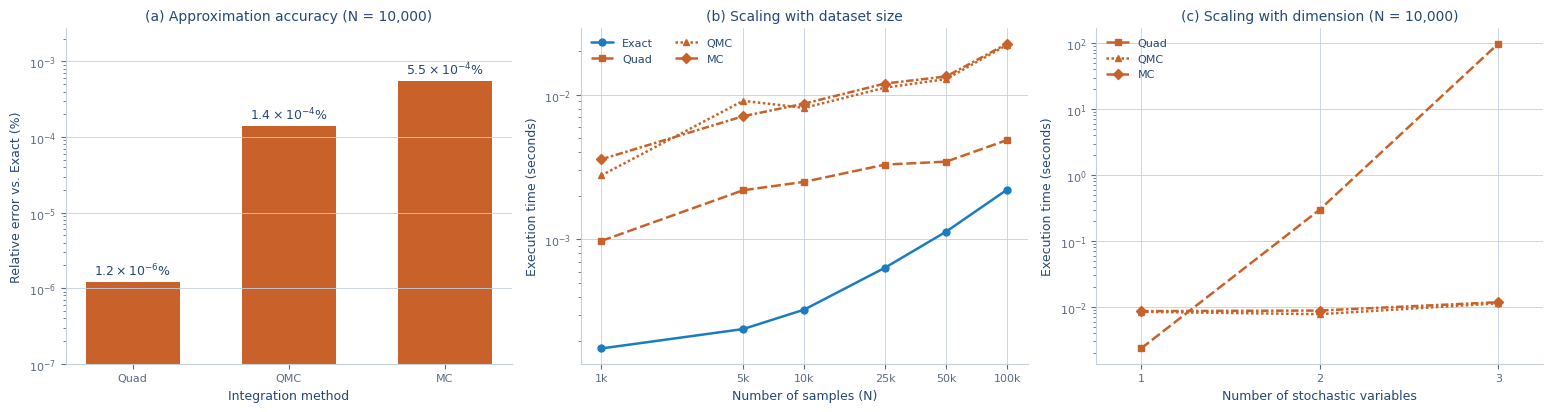

In [26]:
if RUN_EMP_INTEGRATION:
    emp_integration.run_emp_integration(quick=QUICK, results_dir=results_dir)

size, dimensions = figures.load_emp_integration(results_dir)
for name, table in figures.summarize_emp_integration(size, dimensions).items():
    print(f'Mean time (s) and relative error (%), {name}')
    display(table)
display(figures.plot_emp_integration(size, dimensions))

### Training time (Section 9)

In [27]:
if RUN_TIMING:
    # Each reference implementation stops at its own largest size (jss_benchmark.data.LEGACY_MAX_N).
    for impl in ('current', 'legacy'):
        timing.run_timing(
            impl, N_GRID[:2] if QUICK else N_GRID, range(2) if QUICK else range(10), results_dir=results_dir
        )

Mean fit time (s), 95% confidence interval half-width, and number of seeds


,impl,model,n_samples,mean,n,ci95
0,current,csforest,1000,0.059814,10,0.004587
1,current,csforest,3000,0.109709,10,0.020961
2,current,csforest,10000,0.256422,10,0.008259
3,current,csforest,30000,0.797174,10,0.018653
4,current,csforest,100000,2.512803,10,0.062748
5,current,csforest,300000,8.117989,10,0.213297
6,current,csforest,1000000,30.969045,10,0.843660
7,current,cslogit,1000,0.011294,10,0.004323
8,current,cslogit,3000,0.011109,10,0.001126
9,current,cslogit,10000,0.019267,10,0.001715


Speedup (reference / Empulse)


impl,model,n_samples,legacy,current,speedup
0,csforest,1000,32.232397,0.059814,538.879204
1,csforest,3000,40.506498,0.109709,369.216324
2,csforest,10000,74.970685,0.256422,292.371733
3,csforest,30000,133.390460,0.797174,167.329077
4,csforest,100000,405.522462,2.512803,161.382505
5,cslogit,1000,0.072785,0.011294,6.444519
6,cslogit,3000,0.118638,0.011109,10.679680
7,cslogit,10000,0.362215,0.019267,18.799875
8,cslogit,30000,1.045016,0.038805,26.930102
9,cslogit,100000,2.805153,0.047961,58.487935


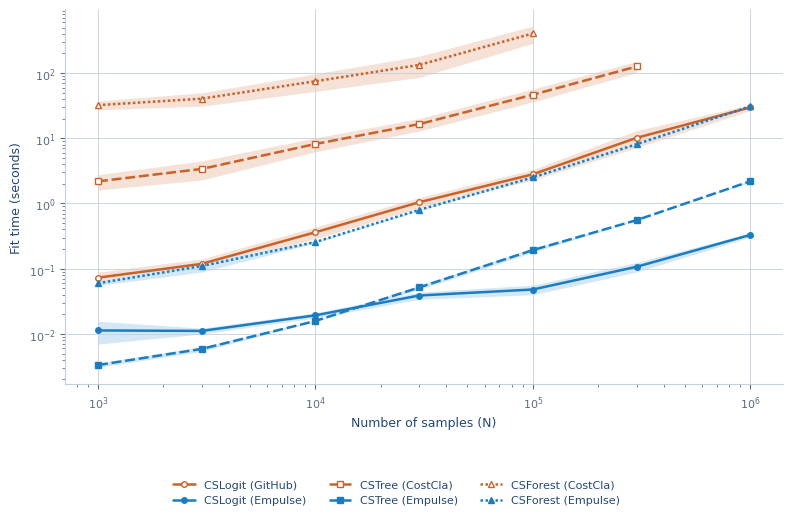

In [28]:
summary = figures.summarize_timing(figures.load_timing(results_dir))

print('Mean fit time (s), 95% confidence interval half-width, and number of seeds')
display(summary)
print('Speedup (reference / Empulse)')
display(figures.speedup_table(summary))
display(figures.plot_scaling(summary))